# Seismic signals preprocessing and exploration

This notebook covers the loading, preprocessing, and exploratory analysis of the seismic acceleration signals. A single preprocessing pipeline is applied to all 66 signals (baseline correction and normalization). A filtered version  excluding the 6 short-signal stations (SURF, BRZ, BHB, CRI, SLZ, SAV) is also saved for use in the moment scaling analysis, which requires signals of sufficient length to produce reliable displacement increment estimates.

## 1. Imports and visualization settings

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import logging
from src.io import build_accelerations, build_metadata
from src.cleaning_signals import preprocess_signals_single, preprocess_signals_long
from src.cleaning_metadata import clean_metadata
from src.plot_settings import set_plot_style
from src.latex_export import preprocess_checks_to_latex
from src.plots import (plot_signal_length_distribution, plot_example_signals,
                       plot_acceleration_distributions, plot_postcheck_single,
                       plot_postcheck_long)
from IPython.display import display
colors = set_plot_style()
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger()
def check(condition, message):
    if condition:
        logger.info(message)
    else:
        raise ValueError(message)
logger.info("Environment ready")

INFO | Environment ready


## 2. Data loading

Raw acceleration data are loaded from the zip archive containing the `.ASC` files.
The function `build_accelerations` extracts the acceleration time series from 
each file and returns a dataframe with columns `file`, `sample`, and `acceleration`.

In [2]:
# Path to the zip file containing metadata and accelerations
zip_path = Path("..") / "data" / "raw" / "query.zip"
# Check if path exists
check(zip_path.exists(), f"Zip file found: {zip_path}")

# Load data
logger.info("Loading accelerations...")
df_acc = build_accelerations(zip_path)
df_meta = build_metadata(zip_path)

# Check if metadata was loaded successfully
check(df_meta is not None, "Metadata dataframe created")
check(len(df_meta) > 0, "Metadata dataframe is not empty")
logger.info(f"Metadata dataframe loaded, shape: {df_meta.shape}\n")

# Check if accelerations were loaded successfully
check(df_acc is not None, "Accelerations dataframe created")
check(len(df_acc) > 0, "Accelerations dataframe is not empty")
logger.info(f"Accelerations dataframe loaded, shape: {df_acc.shape}\n")

# Clean metadata
logger.info("Starting metadata cleaning...")
df_meta_clean = clean_metadata(df_meta)
check(df_meta_clean is not None, "Cleaning returned a dataframe")
check(len(df_meta_clean) > 0, "Cleaned dataframe is not empty")
logger.info(f"Cleaning completed. Shape of cleaned dataframe: {df_meta_clean.shape}")

INFO | Zip file found: ../data/raw/query.zip
INFO | Loading accelerations...
INFO | Metadata dataframe created
INFO | Metadata dataframe is not empty
INFO | Metadata dataframe loaded, shape: (66, 65)

INFO | Accelerations dataframe created
INFO | Accelerations dataframe is not empty
INFO | Accelerations dataframe loaded, shape: (2614815, 3)

INFO | Starting metadata cleaning...
INFO | Cleaning returned a dataframe
INFO | Cleaned dataframe is not empty
INFO | Cleaning completed. Shape of cleaned dataframe: (66, 37)


In [3]:
# Figures output directory
FIGURES_DIR = Path('../figures/02_signals')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
# Check if the directory was created successfully
check(FIGURES_DIR.exists(), f"Figures directory ready: {FIGURES_DIR}")

INFO | Figures directory ready: ../figures/02_signals


## 3. Signals exploration

A first exploration of the raw acceleration signals is performed to understand 
the structure of the dataset before preprocessing. Signal lengths, amplitude 
distributions, and example waveforms are inspected.

### Signal length distribution

The number of samples varies across signals. Understanding the distribution 
of signal lengths is important for deciding how to handle signals of different 
lengths in the aggregated analysis.

INFO | Plotting signal length distribution...
INFO | N files: 66 — lengths range: 6000–56000 samples


Saved: ../figures/02_signals/signal_length_distribution.pdf


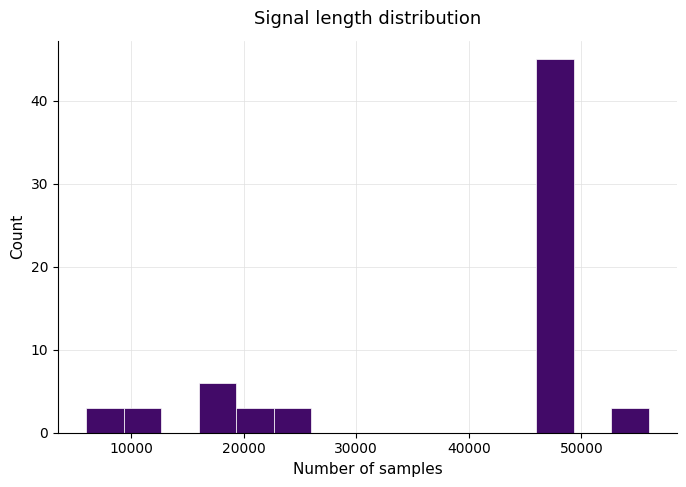

In [4]:
logger.info("Plotting signal length distribution...")
signal_lengths = df_acc.groupby('file')['sample'].max() + 1
logger.info(f"N files: {len(signal_lengths)} — lengths range: "
            f"{signal_lengths.min()}–{signal_lengths.max()} samples")
plot_signal_length_distribution(signal_lengths, output_dir=FIGURES_DIR)

### Example signals

Example acceleration time series are plotted for each component (HNE, HNN, HNZ) 
to visualize the typical structure of the signals: pre-event noise, 
seismic wave arrival, and coda.

Saved: ../figures/02_signals/example_signals.pdf


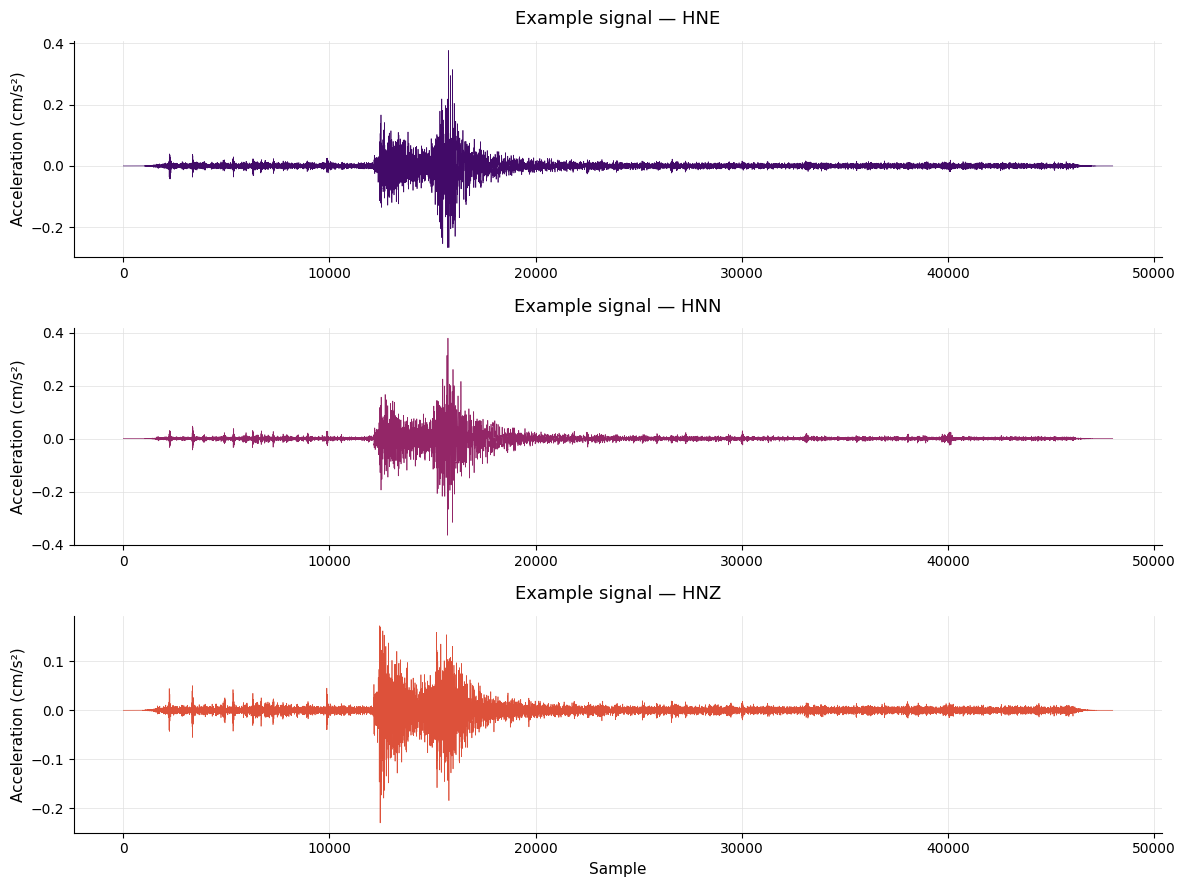

In [5]:
# Display example signals for each stream
plot_example_signals(df_acc, df_meta_clean, output_dir=FIGURES_DIR)

### Acceleration distribution

The distribution of acceleration values is visualized on a logarithmic scale 
to better appreciate the heavy tails of the distribution. The dominance of 
near-zero values reflects the long pre-event and post-event noise windows.

Saved: ../figures/02_signals/acceleration_distribution.pdf


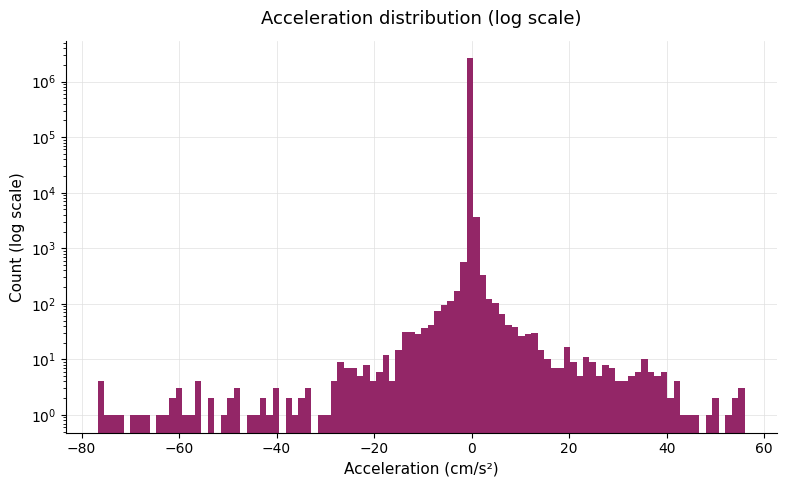

Saved: ../figures/02_signals/acceleration_by_component.pdf


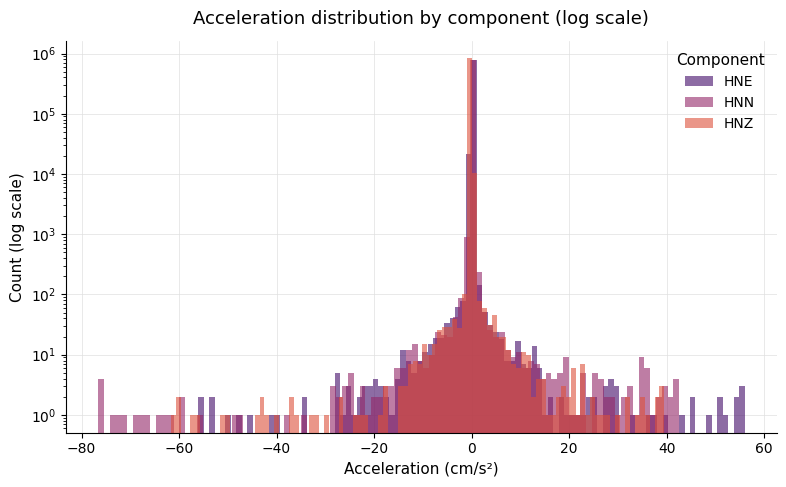

In [6]:
plot_acceleration_distributions(df_acc, df_meta_clean, output_dir=FIGURES_DIR)

### Extreme acceleration values check

Signals with acceleration values below $-40$ cm/s² are identified to verify 
that extreme values are physically plausible and not due to data errors.

In [7]:
# Examine extreme values
print(df_acc[df_acc['acceleration'] < -40]['file'].unique())

['FR.SURF.00.HNE.D.INT-41004391.ACC.MP.ASC'
 'FR.SURF.00.HNN.D.INT-41004391.ACC.MP.ASC'
 'FR.SURF.00.HNZ.D.INT-41004391.ACC.MP.ASC']


## 4. Preprocessing

The preprocessing pipeline consists of two steps applied to all 66 signals:

1. **Baseline correction** — the mean of each signal is subtracted to ensure 
   zero baseline:
   $$a'(t) = a(t) - \bar{a}$$

2. **Normalization** — each signal is divided by its standard deviation to 
   allow comparison across stations with different amplitudes:
   $$\hat{a}(t) = \frac{a'(t)}{\sigma_a}$$

After normalization, each signal has zero mean and unit standard deviation. The resulting dataframe `df_acc_clean` contains all 66 signals and is used for PDF analysis and heavy-tail assessment in notebooks 3 and 4.


### Preprocessing

In [8]:
logger.info("Preprocessing signals — single pipeline")
df_acc_clean = preprocess_signals_single(df_acc)
check(df_acc_clean is not None, "Single pipeline returned a dataframe")
check(df_acc_clean['file'].nunique() == df_acc['file'].nunique(),
      f"All {df_acc['file'].nunique()} files retained")
logger.info(f"Single pipeline preprocessing done. Shape of cleaned datafram: {df_acc_clean.shape}")
display(df_acc_clean.head())
display(df_acc_clean[['acceleration', 'acceleration_normalized']].describe())

INFO | Preprocessing signals — single pipeline
INFO | Single pipeline returned a dataframe
INFO | All 66 files retained
INFO | Single pipeline preprocessing done. Shape of cleaned datafram: (2614815, 4)


,file,sample,acceleration,acceleration_normalized
0,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,0,-6.666667e-10,-3.401661e-08
1,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,1,-6.666667e-10,-3.401661e-08
2,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,2,-6.666667e-10,-3.401661e-08
3,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,3,-6.666667e-10,-3.401661e-08
4,FR.EILF.00.HNE.D.INT-41004391.ACC.MP.ASC,4,-6.666667e-10,-3.401661e-08


,acceleration,acceleration_normalized
count,2.614815e+06,2.614815e+06
mean,4.731320e-20,6.854573e-19
std,3.865810e-01,9.999876e-01
min,-7.663142e+01,-3.300176e+01
25%,-9.249986e-04,-5.137990e-02
50%,-5.000000e-10,-2.139984e-08
75%,9.219988e-04,5.086609e-02
max,5.600939e+01,3.318042e+01


### Post-preprocessing check and saving

The preprocessed dataframe is inspected to verify that baseline correction 
and normalization have been applied correctly. The preprocessed data are 
saved to a parquet file for use in notebook 03.

In [9]:
logger.info("Running quality checks")
# 1. Baseline check — mean per file should be ~0
baseline_check_single = df_acc_clean.groupby('file')['acceleration'].mean()
print("Max residual mean:", baseline_check_single.abs().max())
print("Any mean > 1e-10?", (baseline_check_single.abs() > 1e-10).any())

# 2. Normalization check — std per file should be ~1
norm_check_single = df_acc_clean.groupby('file')['acceleration_normalized'].std()
print("\nMean std:", norm_check_single.mean())
print("Any std far from 1?", ((norm_check_single - 1).abs() > 1e-6).any())

# 3. No NaN or inf
print("\nNaN in acceleration:", df_acc_clean['acceleration'].isna().sum())
print("NaN in acceleration_normalized:", df_acc_clean['acceleration_normalized'].isna().sum())
print("Inf in acceleration:", np.isinf(df_acc_clean['acceleration']).sum())
print("Inf in acceleration_normalized:", np.isinf(df_acc_clean['acceleration_normalized']).sum())

# 4. Shape unchanged
print("\nShape:", df_acc_clean.shape)
print("N files:", df_acc_clean['file'].nunique())

INFO | Running quality checks


Max residual mean: 1.9072905147604626e-17
Any mean > 1e-10? False

Mean std: 1.0
Any std far from 1? False

NaN in acceleration: 0
NaN in acceleration_normalized: 0
Inf in acceleration: 0
Inf in acceleration_normalized: 0

Shape: (2614815, 4)
N files: 66


In [10]:
logger.info("Saving preprocessed data")
try:
    df_acc_clean.to_parquet('../data/processed/acc_preprocessed_all.parquet', index=False)
    logger.info("Saved: acc_preprocessed_all.parquet")
except Exception as e:
    logger.error(f"Error saving file: {e}")

INFO | Saving preprocessed data
INFO | Saved: acc_preprocessed_all.parquet


Saved: ../figures/02_signals/postcheck_single.pdf


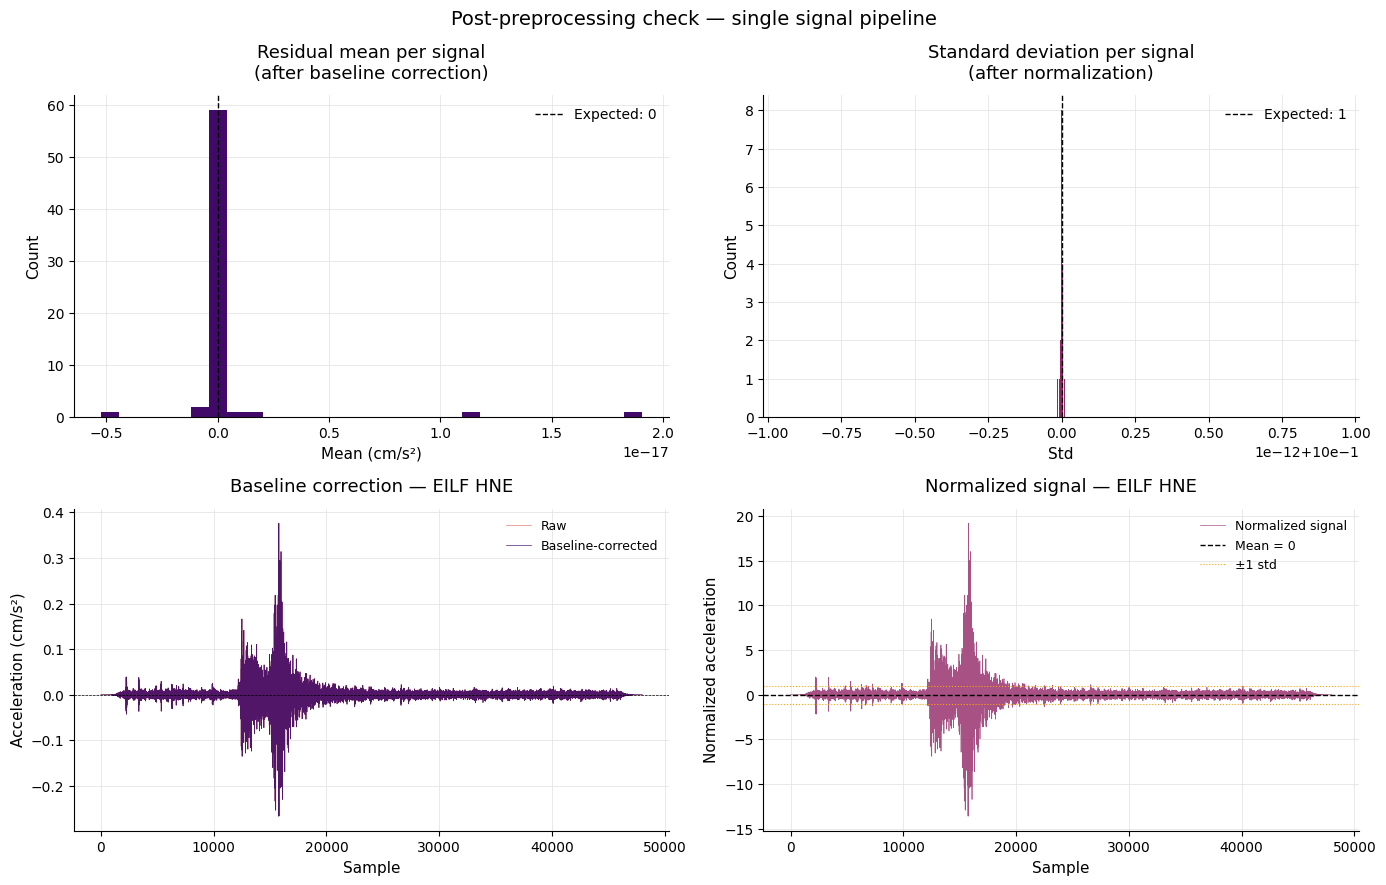

In [11]:
plot_postcheck_single(df_acc, df_acc_clean, output_dir=FIGURES_DIR)

## 5. Filtered preprocessing for moment scaling analysis

The moment scaling analysis (notebooks 3 and 4) requires signals of sufficient length to produce reliable displacement increment estimates at large time scales $\tau$. Signals with fewer than 48,000 samples (stations SURF, BRZ, BHB, CRI, SLZ, SAV) are excluded. The remaining 48 signals are saved separately. The preprocessing pipeline consists of three steps:

1. **Truncation** — only signals with at least $48000$ samples are retained, 
   and all signals are truncated to exactly $48000$ samples. This excludes 
   6 stations (SURF, BRZ, BHB, CRI, SLZ, SAV) whose signals are shorter 
   due to their proximity to the epicenter.

2. **Baseline correction** — same as in the single signal pipeline.

3. **Normalization** — same as in the single signal pipeline.

In [12]:
# Display signal length distribution
signal_lengths = df_acc.groupby('file')['sample'].max() + 1
pd.set_option('display.max_rows', None)
print(signal_lengths.sort_values())
pd.reset_option('display.max_rows')

file
FR.SURF.00.HNE.D.INT-41004391.ACC.MP.ASC     6000
FR.SURF.00.HNZ.D.INT-41004391.ACC.MP.ASC     6000
FR.SURF.00.HNN.D.INT-41004391.ACC.MP.ASC     6000
IT.BRZ..HGE.D.INT-41004391.ACC.MP.ASC       11001
IT.BRZ..HGZ.D.INT-41004391.ACC.MP.ASC       11001
IT.BRZ..HGN.D.INT-41004391.ACC.MP.ASC       11001
GU.BHB..HNE.D.INT-41004391.ACC.MP.ASC       16601
GU.BHB..HNN.D.INT-41004391.ACC.MP.ASC       16601
GU.BHB..HNZ.D.INT-41004391.ACC.MP.ASC       16601
IT.CRI..HNZ.D.INT-41004391.ACC.MP.ASC       19001
IT.CRI..HNE.D.INT-41004391.ACC.MP.ASC       19001
IT.CRI..HNN.D.INT-41004391.ACC.MP.ASC       19001
IT.SLZ..HNZ.D.INT-41004391.ACC.MP.ASC       20001
IT.SLZ..HNN.D.INT-41004391.ACC.MP.ASC       20001
IT.SLZ..HNE.D.INT-41004391.ACC.MP.ASC       20001
IT.SAV..HGE.D.INT-41004391.ACC.MP.ASC       23001
IT.SAV..HGN.D.INT-41004391.ACC.MP.ASC       23001
IT.SAV..HGZ.D.INT-41004391.ACC.MP.ASC       23001
FR.SAOF.00.HNN.D.INT-41004391.ACC.MP.ASC    48000
FR.REVF.00.HN2.D.INT-41004391.ACC.MP.ASC    4

### Preprocessing

In [13]:
logger.info("Preprocessing signals — long signals pipeline...")
df_acc_long = preprocess_signals_long(df_acc)
n_excluded = df_acc['file'].nunique() - df_acc_long['file'].nunique()
check(df_acc_long is not None, "Long pipeline returned a dataframe")
logger.info(f"Long pipeline done. Files retained: {df_acc_long['file'].nunique()} "
            f"({n_excluded} excluded). Shape: {df_acc_long.shape}")
display(df_acc_long.describe())

INFO | Preprocessing signals — long signals pipeline...
INFO | Long pipeline returned a dataframe
INFO | Long pipeline done. Files retained: 48 (18 excluded). Shape: (2328000, 4)


,sample,acceleration,acceleration_normalized
count,2.328000e+06,2.328000e+06,2.328000e+06
mean,2.428816e+04,1.307190e-20,7.405540e-19
std,1.407391e+04,1.992689e-02,9.999899e-01
min,0.000000e+00,-9.768020e-01,-3.300176e+01
25%,1.212475e+04,-8.209985e-04,-5.016902e-02
50%,2.424950e+04,-5.000000e-10,-2.139984e-08
75%,3.637425e+04,8.189995e-04,4.972788e-02
max,5.599900e+04,7.343670e-01,3.318042e+01


### Post-preprocessing check and saving

The preprocessed dataframe is inspected to verify that filtering, baseline correction, and normalization have been applied correctly. The preprocessed data are saved to a parquet file for use in notebooks 3 and 4.

In [14]:
logger.info("Running quality checks")
# 1. Filter check — only files with >= 48000 samples should be retained
signal_lengths_long = df_acc_long.groupby('file')['sample'].max() + 1
print("N files after filtering:", df_acc_long['file'].nunique())
print("Signal lengths:\n", signal_lengths_long.value_counts())

# 2. Baseline check — mean per file should be ~0
baseline_check_long = df_acc_long.groupby('file')['acceleration'].mean()
print("\nMax residual mean:", baseline_check_long.abs().max())
print("Any mean > 1e-10?", (baseline_check_long.abs() > 1e-10).any())

# 3. Normalization check — std per file should be ~1
norm_check_long = df_acc_long.groupby('file')['acceleration_normalized'].std()
print("\nMean std:", norm_check_long.mean())
print("Any std far from 1?", ((norm_check_long - 1).abs() > 1e-6).any())

# 4. No NaN or inf
print("\nNaN in acceleration:", df_acc_long['acceleration'].isna().sum())
print("NaN in acceleration_normalized:", df_acc_long['acceleration_normalized'].isna().sum())
print("Inf in acceleration:", np.isinf(df_acc_long['acceleration']).sum())
print("Inf in acceleration_normalized:", np.isinf(df_acc_long['acceleration_normalized']).sum())

# 5. Shape
print("\nShape:", df_acc_long.shape)

INFO | Running quality checks


N files after filtering: 48
Signal lengths:
 sample
48000    45
56000     3
Name: count, dtype: int64

Max residual mean: 1.2916139839021171e-19
Any mean > 1e-10? False

Mean std: 1.0000000000000002
Any std far from 1? False

NaN in acceleration: 0
NaN in acceleration_normalized: 0
Inf in acceleration: 0
Inf in acceleration_normalized: 0

Shape: (2328000, 4)


In [15]:
logger.info("Saving preprocessed data")
try:
    df_acc_long.to_parquet('../data/processed/acc_preprocessed_long.parquet', index=False)
    logger.info("Saved: acc_preprocessed_long.parquet")
except Exception as e:
    logger.error(f"Error saving file: {e}")

INFO | Saving preprocessed data
INFO | Saved: acc_preprocessed_long.parquet


Saved: ../figures/02_signals/postcheck_long.pdf


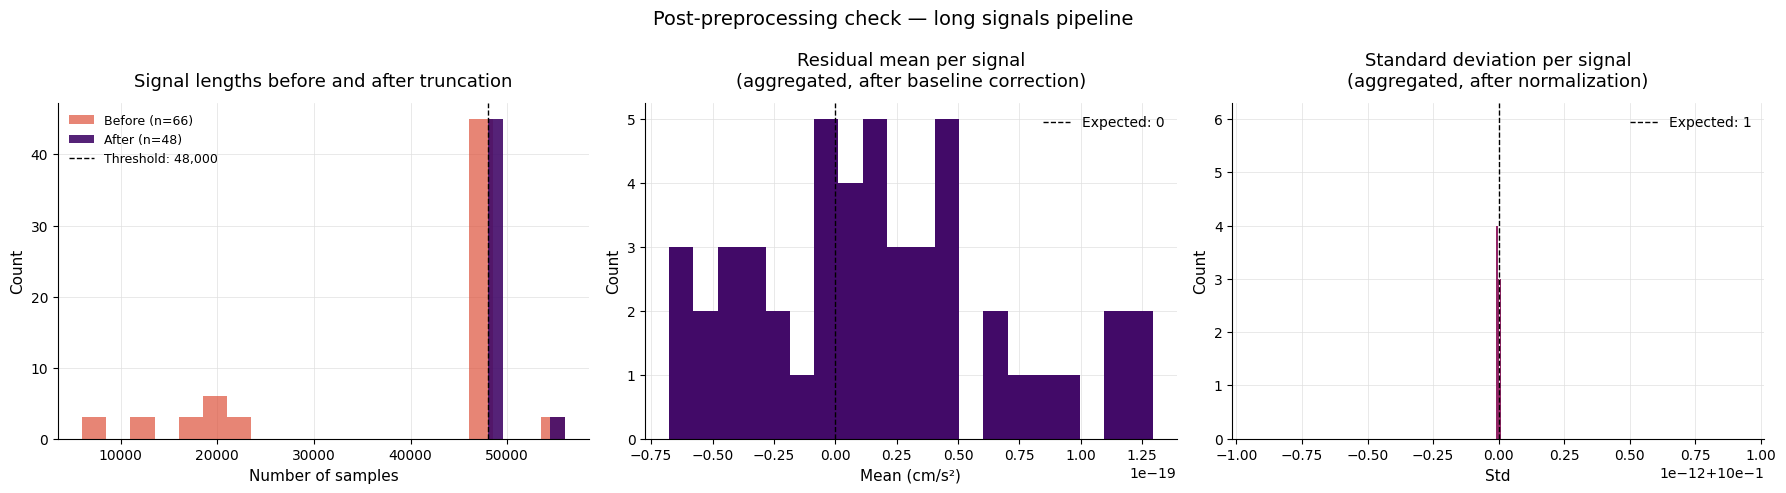

In [16]:
plot_postcheck_long(df_acc, df_acc_long, output_dir=FIGURES_DIR)

## Summary

In [17]:
# Variabili per la summary table
signal_lengths_raw   = df_acc.groupby('file')['sample'].max() + 1
baseline_check_agg   = df_acc_long.groupby('file')['acceleration'].mean()
norm_check_agg       = df_acc_long.groupby('file')['acceleration_normalized'].std()
# Single pipeline
bl_max_single   = baseline_check_single.abs().max()
bl_pass_single  = bl_max_single < 1e-10
std_mean_single = norm_check_single.mean()
std_pass_single = ((norm_check_single - 1).abs() > 1e-6).sum() == 0
nan_acc_single  = df_acc_clean['acceleration'].isna().sum()
nan_norm_single = df_acc_clean['acceleration_normalized'].isna().sum()
inf_acc_single  = np.isinf(df_acc_clean['acceleration']).sum()
inf_norm_single = np.isinf(df_acc_clean['acceleration_normalized']).sum()
n_files_single  = df_acc_clean['file'].nunique()

# Long signals only pipeline
bl_max_agg   = baseline_check_agg.abs().max()
bl_pass_agg  = bl_max_agg < 1e-10
std_mean_agg = norm_check_agg.mean()
std_pass_agg = ((norm_check_agg - 1).abs() > 1e-6).sum() == 0
nan_acc_agg  = df_acc_long['acceleration'].isna().sum()
nan_norm_agg = df_acc_long['acceleration_normalized'].isna().sum()
inf_acc_agg  = np.isinf(df_acc_long['acceleration']).sum()
inf_norm_agg = np.isinf(df_acc_long['acceleration_normalized']).sum()
n_files_agg  = df_acc_long['file'].nunique()
trunc_excluded = len(signal_lengths_raw) - n_files_agg

rows = [
    ('Files retained',
     f'{n_files_single} / {len(signal_lengths_raw)}',
     f'{n_files_agg} / {len(signal_lengths_raw)} ({trunc_excluded} excluded)',
     '—',           '—'),
    ('Max residual mean (cm/s²)',
     f'{bl_max_single:.2e}',
     f'{bl_max_agg:.2e}',
     '< 1e-10',     '\\checkmark' if (bl_pass_single and bl_pass_agg) else '\\times'),
    ('Mean std (normalized)',
     f'{std_mean_single:.8f}',
     f'{std_mean_agg:.8f}',
     '$\\approx 1$', '\\checkmark' if (std_pass_single and std_pass_agg) else '\\times'),
    ('NaN in acceleration',
     str(nan_acc_single),
     str(nan_acc_agg),
     '0',           '\\checkmark' if nan_acc_single == 0 and nan_acc_agg == 0 else '\\times'),
    ('NaN in acceleration\_normalized',
     str(nan_norm_single),
     str(nan_norm_agg),
     '0',           '\\checkmark' if nan_norm_single == 0 and nan_norm_agg == 0 else '\\times'),
    ('Inf in acceleration',
     str(inf_acc_single),
     str(inf_acc_agg),
     '0',           '\\checkmark' if inf_acc_single == 0 and inf_acc_agg == 0 else '\\times'),
    ('Inf in acceleration\_normalized',
     str(inf_norm_single),
     str(inf_norm_agg),
     '0',           '\\checkmark' if inf_norm_single == 0 and inf_norm_agg == 0 else '\\times'),
]

df_check = pd.DataFrame(rows, columns=['Check', 'Single pipeline',
                                        'Aggregated pipeline', 'Expected', 'Pass'])
display(df_check)

,Check,Single pipeline,Aggregated pipeline,Expected,Pass
0,Files retained,66 / 66,48 / 66 (18 excluded),—,—
1,Max residual mean (cm/s²),1.91e-17,1.29e-19,< 1e-10,\checkmark
2,Mean std (normalized),1.00000000,1.00000000,$\approx 1$,\checkmark
3,NaN in acceleration,0,0,0,\checkmark
4,NaN in acceleration\_normalized,0,0,0,\checkmark
5,Inf in acceleration,0,0,0,\checkmark
6,Inf in acceleration\_normalized,0,0,0,\checkmark


In [18]:
latex_table = preprocess_checks_to_latex(
    rows, output_path='../data/processed/preprocess_checks_table.tex')
logger.info("LaTeX table saved: preprocess_checks_table.tex")

INFO | LaTeX table saved: preprocess_checks_table.tex


Saved to: ../data/processed/preprocess_checks_table.tex


In [20]:
import numpy as np
import pandas as pd

print("="*80)
print("CONFRONTO acceleration vs acceleration_normalized")
print("="*80)

# 1. Verifica che entrambe le colonne esistano
if 'acceleration_normalized' not in df_acc_long.columns:
    print("❌ ERRORE: colonna 'acceleration_normalized' non trovata!")
    print(f"Colonne disponibili: {df_acc_long.columns.tolist()}")
else:
    # Confronto globale
    acc = df_acc_long['acceleration'].values
    acc_norm = df_acc_long['acceleration_normalized'].values
    
    # Conta maggiori, minori, uguali
    greater = np.sum(acc > acc_norm)
    less = np.sum(acc < acc_norm)
    equal = np.sum(acc == acc_norm)
    total = len(acc)
    
    print(f"\nConfronti su {total:,} campioni totali:")
    print(f"  acceleration > acceleration_normalized:  {greater:,} ({100*greater/total:.2f}%)")
    print(f"  acceleration < acceleration_normalized:  {less:,} ({100*less/total:.2f}%)")
    print(f"  acceleration = acceleration_normalized:  {equal:,} ({100*equal/total:.2f}%)")
    
    # Differenza media
    diff = acc - acc_norm
    print(f"\nDifferenza (acceleration - acceleration_normalized):")
    print(f"  Mean:   {np.mean(diff):.6f}")
    print(f"  Median: {np.median(diff):.6f}")
    print(f"  Std:    {np.std(diff):.6f}")
    print(f"  Min:    {np.min(diff):.6f}")
    print(f"  Max:    {np.max(diff):.6f}")
    
    # Confronto per alcuni file
    print("\n" + "="*80)
    print("CONFRONTO PER FILE (primi 10 file):")
    print("="*80)
    print(f"{'File':<15} {'N_greater':<12} {'N_less':<12} {'N_equal':<12} {'%Greater':<10} {'%Less':<10} {'%Equal':<10}")
    print("-"*80)
    
    for i, file in enumerate(df_acc_long['file'].unique()[:10]):
        df_file = df_acc_long[df_acc_long['file'] == file]
        acc_f = df_file['acceleration'].values
        acc_norm_f = df_file['acceleration_normalized'].values
        
        greater_f = np.sum(acc_f > acc_norm_f)
        less_f = np.sum(acc_f < acc_norm_f)
        equal_f = np.sum(acc_f == acc_norm_f)
        total_f = len(acc_f)
        
        station = file.split('.')[1]
        print(f"{station:<15} {greater_f:<12} {less_f:<12} {equal_f:<12} "
              f"{100*greater_f/total_f:<10.2f} {100*less_f/total_f:<10.2f} {100*equal_f/total_f:<10.2f}")

print("\n" + "="*80)
print("STD PER FILE (PRE-PREPROCESSING)")
print("="*80)

# Carica dati raw (pre-preprocessing)
from src.io import build_accelerations
df_acc_raw = build_accelerations('../data/raw/query.zip')

# Filtra solo i file lunghi (stessi di df_acc_long)
long_files = df_acc_long['file'].unique()
df_acc_raw_long = df_acc_raw[df_acc_raw['file'].isin(long_files)]

# Calcola std per file
print(f"\n{'File':<15} {'Station':<10} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12} {'N_samples':<12}")
print("-"*80)

std_stats = []
for file in sorted(long_files):
    data = df_acc_raw_long[df_acc_raw_long['file'] == file]['acceleration'].values
    
    station = file.split('.')[1]
    stream = file.split('.')[3]
    
    mean_val = np.mean(data)
    std_val = np.std(data)
    min_val = np.min(data)
    max_val = np.max(data)
    n_samples = len(data)
    
    std_stats.append({
        'file': file,
        'station': station,
        'stream': stream,
        'mean': mean_val,
        'std': std_val,
        'min': min_val,
        'max': max_val,
        'n_samples': n_samples
    })
    
    print(f"{station}_{stream:<10} {station:<10} {mean_val:<12.6f} {std_val:<12.6f} "
          f"{min_val:<12.3f} {max_val:<12.3f} {n_samples:<12}")

df_std_stats = pd.DataFrame(std_stats)

print("\n" + "="*80)
print("STATISTICHE AGGREGATE (PRE-PREPROCESSING):")
print("="*80)
print(f"Media delle std:     {df_std_stats['std'].mean():.6f}")
print(f"Mediana delle std:   {df_std_stats['std'].median():.6f}")
print(f"Min std:             {df_std_stats['std'].min():.6f}")
print(f"Max std:             {df_std_stats['std'].max():.6f}")
print(f"Std delle std:       {df_std_stats['std'].std():.6f}")

print(f"\nMedia delle medie:   {df_std_stats['mean'].mean():.6f}")
print(f"Media dei |mean|:    {df_std_stats['mean'].abs().mean():.6f}")
print(f"Max |mean|:          {df_std_stats['mean'].abs().max():.6f}")

print("\n" + "="*80)
print("TOP 10 FILE PER STD (PRE-PREPROCESSING):")
print("="*80)
df_top_std = df_std_stats.sort_values('std', ascending=False).head(10)
print(df_top_std[['station', 'stream', 'mean', 'std', 'min', 'max']].to_string(index=False))

print("\n" + "="*80)

CONFRONTO acceleration vs acceleration_normalized

Confronti su 2,328,000 campioni totali:
  acceleration > acceleration_normalized:  1,171,967 (50.34%)
  acceleration < acceleration_normalized:  1,156,033 (49.66%)
  acceleration = acceleration_normalized:  0 (0.00%)

Differenza (acceleration - acceleration_normalized):
  Mean:   -0.000000
  Median: 0.000000
  Std:    0.981740
  Min:    -32.472237
  Max:    32.024957

CONFRONTO PER FILE (primi 10 file):
File            N_greater    N_less       N_equal      %Greater   %Less      %Equal    
--------------------------------------------------------------------------------
EILF            24428        23572        0            50.89      49.11      0.00      
EILF            23469        24531        0            48.89      51.11      0.00      
EILF            24332        23668        0            50.69      49.31      0.00      
ESCA            23543        24457        0            49.05      50.95      0.00      
ESCA            23372